In [169]:
import pandas as pd
import numpy as np

In [170]:
df_train = pd.read_csv('/content/Team-Megaforce-Ai-project/train_data.csv')
df_test = pd.read_csv('/content/Team-Megaforce-Ai-project/test_data.csv')
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001430,Female,No,0,Graduate,No,4166,0.0,44.0,360.0,1.0,Semiurban,Y
1,LP002347,Male,Yes,0,Graduate,No,3246,1417.0,138.0,360.0,1.0,Semiurban,Y
2,LP001528,Male,No,0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural,N
3,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
4,LP002368,Male,Yes,2,Graduate,No,5935,0.0,133.0,360.0,1.0,Semiurban,Y


In [171]:
df_train.info()
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            304 non-null    object 
 1   Gender             301 non-null    object 
 2   Married            304 non-null    object 
 3   Dependents         297 non-null    object 
 4   Education          304 non-null    object 
 5   Self_Employed      287 non-null    object 
 6   ApplicantIncome    304 non-null    int64  
 7   CoapplicantIncome  304 non-null    float64
 8   LoanAmount         304 non-null    float64
 9   Loan_Amount_Term   295 non-null    float64
 10  Credit_History     281 non-null    float64
 11  Property_Area      304 non-null    object 
 12  Loan_Status        304 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 31.0+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,304.000000,304.000000,304.000000,295.000000,281.000000
mean,3583.828947,1220.645132,105.282895,342.101695,0.822064
std,1366.102888,1732.098606,28.696412,67.192306,0.383141
min,210.000000,0.000000,17.000000,12.000000,0.000000
25%,2651.000000,0.000000,90.000000,360.000000,1.000000
50%,3365.500000,953.000000,110.500000,360.000000,1.000000
75%,4284.250000,2045.000000,128.000000,360.000000,1.000000
max,9703.000000,20000.000000,150.000000,480.000000,1.000000


In [172]:
df_train.isnull().sum()

,0
Loan_ID,0
Gender,3
Married,0
Dependents,7
Education,0
Self_Employed,17
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,9


In [173]:
df_train.drop(['Loan_ID','Gender'], axis=1, inplace=True)
df_test.drop(['Loan_ID','Gender'], axis=1, inplace=True)

In [174]:
df_train['Dependents'] = df_train['Dependents'].replace('3+', 3).astype(float)
df_train['Dependents'] = df_train['Dependents'].fillna(df_train['Dependents'].mean())
df_train['Loan_Amount_Term'] = df_train['Loan_Amount_Term'].fillna(df_train['Loan_Amount_Term'].mean())
df_train['Self_Employed'] = df_train['Self_Employed'].fillna(df_train['Self_Employed'].mode()[0])
df_train['Credit_History'] = df_train['Credit_History'].fillna(df_train['Credit_History'].mean())

In [175]:
df_test['Dependents'] = df_test['Dependents'].replace('3+', 3).astype(float)
df_test['Dependents'] = df_test['Dependents'].fillna(df_test['Dependents'].mean())
df_test['Loan_Amount_Term'] = df_test['Loan_Amount_Term'].fillna(df_test['Loan_Amount_Term'].mean())
df_test['Self_Employed'] = df_test['Self_Employed'].fillna(df_test['Self_Employed'].mode()[0])
df_test['Credit_History'] = df_test['Credit_History'].fillna(df_test['Credit_History'].mean())

In [176]:
df_train.isnull().sum()

,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


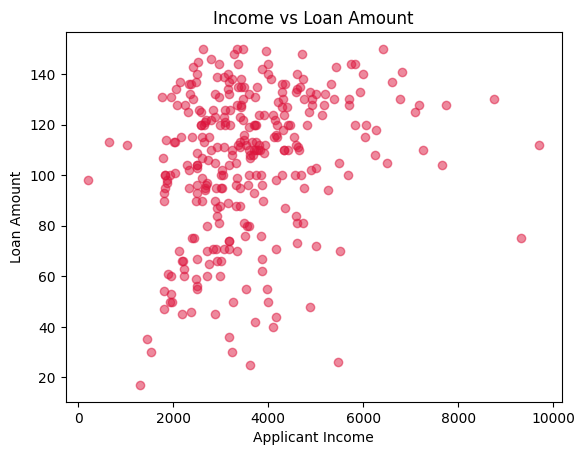

In [177]:
import matplotlib.pyplot as plt
plt.scatter(df_train['ApplicantIncome'], df_train['LoanAmount'], alpha=0.5,color='crimson')
plt.title('Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

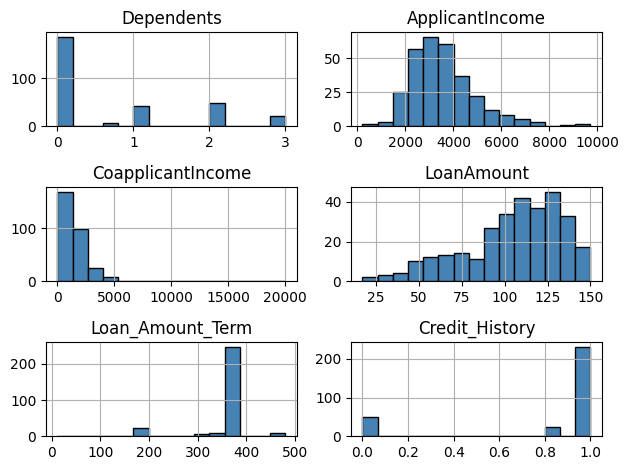

In [178]:
df_train.hist(bins=15 ,color='steelblue',edgecolor='black')
plt.tight_layout()
plt.show()

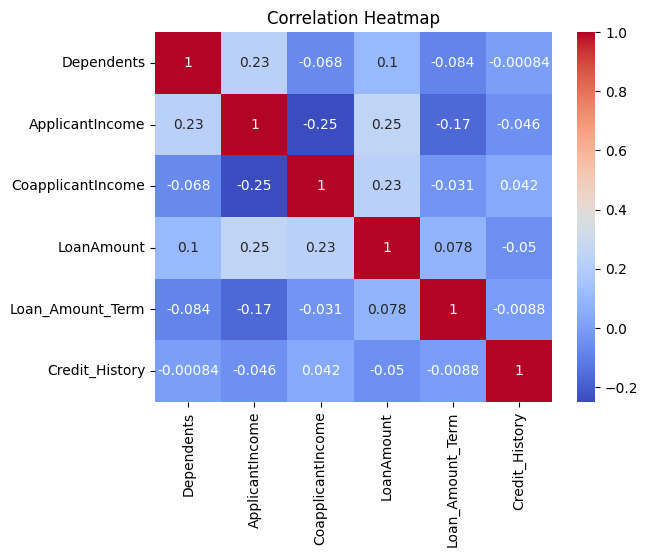

In [179]:
import seaborn as sns
numeric_df = df_train.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

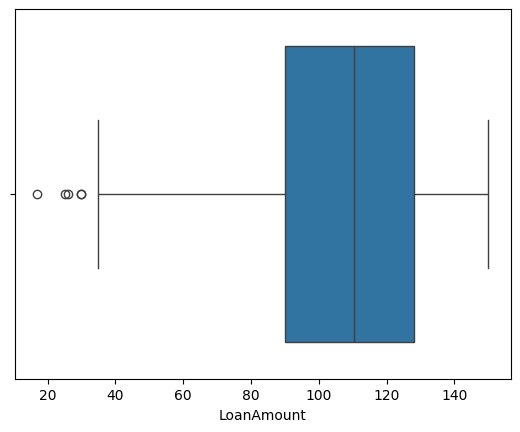

In [180]:
sns.boxplot(x=df_train['LoanAmount'])
plt.show()

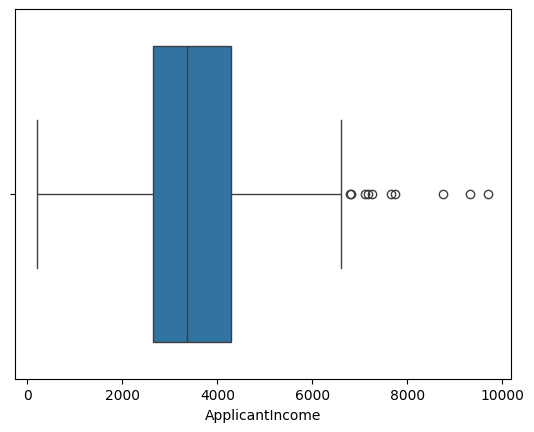

In [181]:
sns.boxplot(x=df_train['ApplicantIncome'])
plt.show()

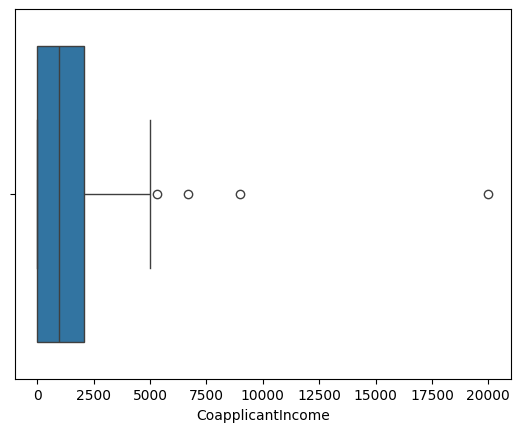

In [182]:
sns.boxplot(x=df_train['CoapplicantIncome'])
plt.show()

In [183]:
df_train['ApplicantIncome'] = np.log1p(df_train['ApplicantIncome'])
df_train['CoapplicantIncome'] = np.log1p(df_train['CoapplicantIncome'])
df_train['LoanAmount'] = np.log1p(df_train['LoanAmount'])

df_test['ApplicantIncome'] = np.log1p(df_test['ApplicantIncome'])
df_test['CoapplicantIncome'] = np.log1p(df_test['CoapplicantIncome'])
df_test['LoanAmount'] = np.log1p(df_test['LoanAmount'])

df_train['TotalIncome'] = df_train['ApplicantIncome'] + df_train['CoapplicantIncome']
df_test['TotalIncome'] = df_test['ApplicantIncome'] + df_test['CoapplicantIncome']

In [184]:
numeric_df['Loan_Status'] = df_train['Loan_Status']
numeric_df['Loan_Status'] = numeric_df['Loan_Status'].map({'Y': 1, 'N': 0})
print(numeric_df.corr()['Loan_Status'])

Dependents           0.003908
ApplicantIncome     -0.064381
CoapplicantIncome    0.126424
LoanAmount           0.039913
Loan_Amount_Term    -0.079148
Credit_History       0.623175
Loan_Status          1.000000
Name: Loan_Status, dtype: float64


In [185]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Married', 'Education', 'Self_Employed', 'Property_Area']


for col in cat_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.transform(df_test[col])


le_loan_status = LabelEncoder()
df_train['Loan_Status'] = le_loan_status.fit_transform(df_train['Loan_Status'].astype(str))
df_test['Loan_Status'] = le_loan_status.transform(df_test['Loan_Status'].astype(str))

In [186]:
X_train = df_train.drop('Loan_Status', axis=1)
y_train = df_train['Loan_Status']

In [187]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [188]:
X_test = df_test.drop('Loan_Status', axis=1)
y_test = df_test['Loan_Status']
X_test = scaler.transform(X_test)

In [189]:
from sklearn.svm import SVC
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

In [190]:
y_pred = model.predict(X_test)

In [191]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8181818181818182


In [192]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
model.get_params()

              precision    recall  f1-score   support

           0       1.00      0.33      0.50        21
           1       0.80      1.00      0.89        56

    accuracy                           0.82        77
   macro avg       0.90      0.67      0.69        77
weighted avg       0.85      0.82      0.78        77

[[ 7 14]
 [ 0 56]]


{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [193]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'class_weight': None, 'gamma': 0.1}
0.8585792349726777
